# Finetune Jina v5-nano for Arabic Dictionary Retrieval (Corrected)

Finetunes `jina-embeddings-v5-text-nano-retrieval` (212M params, 768-dim, last-token pooling,
EuroBERT backbone) on curated Arabic WordNet triplets.

**Hardware:** Kaggle 2x Tesla T4 GPUs (16GB VRAM each, Turing arch, native FP16 tensor cores)

## Corrections from v1 (Colab Notebook)

| # | Error in v1 | Fix in v2 |
|---|-------------|----------|
| P0-1 | Gradient accumulation does NOT increase contrastive batch size. MNRL `forward()` is per-micro-batch. `batch_size=8, grad_accum=4` meant only 15 negatives/query (not 32). | `CachedMultipleNegativesRankingLoss` (GradCache). `per_device_train_batch_size=32`, `mini_batch_size=16`. Each query sees 2x32-1 = **63 negatives** per GPU. |
| P0-2 | MNRL negatives math wrong: with triplets, pool = 2B, each anchor sees 2B-1 negatives, not B-1. | Correctly documented: 2x32-1 = 63 negatives. |
| P0-3 | Train/test distribution shift. Training anchors combine lemma+definition; production queries are lemma-only or definition-only. | Decompose each anchor into 3 variants (combined, lemma-only, definition-only). 4,660 -> ~13,980 train triplets. |
| P1-4 | `warmup_steps=582` = 80% of training, not 10%. | `warmup_ratio=0.1` |
| P1-5 | `bf16=True` on T4 = software emulation, no speedup. | `fp16=True` (native T4 tensor cores) |
| P1-6 | `metric_for_best_model` never set; defaulted to eval_loss. | Set explicitly to NDCG@10 + `greater_is_better=True` |
| P1-7 | Parameter count 239M includes LoRA adapters; pre-merged = 211,766,016 (~212M). | Corrected throughout. |
| P2-8 | "32 eval synsets" is actually 28 (`int(137*0.8)=109` train, 28 eval). | Corrected. |

| | Original | After Decomposition |
|---|---|---|
| **Train triplets** | 4,660 | ~13,980 |
| **Eval triplets** | 1,512 | ~4,536 |
| **Train synsets** | 109 | 109 (unchanged) |
| **Eval synsets** | 28 | 28 (unchanged) |
| **Negatives per query** | 15 (was claimed 32) | 63 per GPU |

## 1. Setup

In [1]:
# Kaggle has CUDA/PyTorch pre-installed — no conda needed
!pip install -q -U "sentence-transformers[train]" datasets wandb
# Kaggle has CUDA/PyTorch pre-installed — no conda needed\n# Note: faiss is NOT needed — the InformationRetrievalEvaluator uses PyTorch internally\n# peft is for the optional v5-small LoRA section at the end\n!pip install -q -U \"sentence-transformers[train]\" datasets peft wandb"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 9.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 71.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 42.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.4/512.4 kB 30.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


In [3]:
# Kaggle Secrets — authenticate HuggingFace and WandB
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

import os
os.environ["HF_TOKEN"] = user_secrets.get_secret("HF_token")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")


In [5]:
# Verify GPU availability: expect 2x Tesla T4
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"\nGPU {i}: {props.name}")
    print(f"  VRAM: {props.total_memory / 1e9:.1f} GB")
    print(f"  Compute capability: {props.major}.{props.minor}")
    if props.major == 7 and props.minor == 5:
        print("  -> Turing architecture: native FP16 tensor cores, NO native bf16")

assert torch.cuda.device_count() >= 2, "Expected 2x T4 GPUs on Kaggle"
print("\nGPU check passed.")

PyTorch: 2.9.0+cu126
CUDA available: True
GPU count: 2

GPU 0: Tesla T4
  VRAM: 15.6 GB
  Compute capability: 7.5
  -> Turing architecture: native FP16 tensor cores, NO native bf16

GPU 1: Tesla T4
  VRAM: 15.6 GB
  Compute capability: 7.5
  -> Turing architecture: native FP16 tensor cores, NO native bf16

GPU check passed.


In [6]:
import json
import hashlib
import os
import gc
from pathlib import Path
from collections import Counter

import numpy as np
from datasets import Dataset
from sentence_transformers import SentenceTransformer
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from sentence_transformers.losses import (
    CachedMultipleNegativesRankingLoss,
    MatryoshkaLoss,
)
from sentence_transformers import (
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
)
from sentence_transformers.training_args import BatchSamplers

## 2. Load Data

Upload `triplets_train.jsonl`, `triplets_eval.jsonl`, and `stats.json` as a Kaggle dataset
named `jina-finetune-data`. Adjust `DATA_DIR` if your dataset name differs.

In [8]:
# Kaggle dataset input path — adjust dataset name as needed
DATA_DIR = Path("/kaggle/input/datasets/salah1992/jina-finetune-data")

# Verify contents
for f in sorted(DATA_DIR.iterdir()):
    size = f.stat().st_size
    print(f"  {f.name:30s} {size/1024:.0f} KB")

stats = json.loads((DATA_DIR / "stats.json").read_text(encoding="utf-8"))
print(f"\nOriginal train triplets: {stats['train_triplets']:,}")
print(f"Original eval triplets:  {stats['eval_triplets']:,}")
print(f"Synsets processed:       {stats['synsets_processed']}")
print(f"Negative distribution:   {stats['negative_source_distribution']}")

  stats.json                     1 KB
  triplets_eval.jsonl            7504 KB
  triplets_train.jsonl           23185 KB

Original train triplets: 4,660
Original eval triplets:  1,512
Synsets processed:       137
Negative distribution:   {'original': 20, 'step05': 224, 'soft_negative': 5928}


In [9]:
def load_triplets_raw(path):
    """Load JSONL triplets, keeping anchor/positive/negative."""
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            rows.append({
                "anchor": obj["anchor"],
                "positive": obj["positive"],
                "negative": obj["negative"],
            })
    return rows

raw_train = load_triplets_raw(DATA_DIR / "triplets_train.jsonl")
raw_eval = load_triplets_raw(DATA_DIR / "triplets_eval.jsonl")

print(f"Original train: {len(raw_train):,} triplets")
print(f"Original eval:  {len(raw_eval):,} triplets")

# Spot-check first example
print("\n" + "=" * 60)
print("ANCHOR:", raw_train[0]["anchor"][:150])
print("\nPOSITIVE:", raw_train[0]["positive"][:200])
print("\nNEGATIVE:", raw_train[0]["negative"][:200])

Original train: 4,660 triplets
Original eval:  1,512 triplets

ANCHOR: Query: كَيْنُونَة كِيَان — ما يُدرَك أو يُعرَف أو يُستدَلّ على وجوده المستقل، سواء أكان حيًّا أم غير حيّ

POSITIVE: Document: # كيان (جذر: كن)

## Data and AI Glossary
*معجم البيانات والذكاء الاصطناعي (2024)*
EN: Entity

شيء مادي أو غير مادي يمكن التعرُّف عليه وتمييزه بوضوح.

## Dictionary of Information Technology

NEGATIVE: Document: # (1) كينونة؛ وجود
(2) الكائنات مجتمعةً
(3) كائن
(4) حياة؛ بقاء struggle for existence
(5) أسلوبُ حياةٍ.


## Al-Mawrid Al-Hadeeth
*المورد الحديث (2008)*
EN: existence

(1) كينونة؛ وجود
(2) 


## 3. Anchor Decomposition (Fix P0-3: Distribution Shift)

**Problem:** Training anchors combine lemma + definition:
`"Query: \u0643\u0650\u064a\u064e\u0627\u0646 \u2014 \u0645\u0627 \u064a\u064f\u062f\u0631\u064e\u0643..."`, but production queries are either
lemma-only or definition-only (via `queries.py`). The model learns a shortcut:
lexical overlap between anchor lemma tokens and document headword.

**Fix:** Decompose each training anchor into 3 variants:
1. **Combined** (original): `"Query: lemmas \u2014 definition"`
2. **Lemma-only**: `"Query: lemmas"`
3. **Definition-only**: `"Query: definition_text"`

Positive and negative documents stay the same. This forces the model to learn
both retrieval paths: lemma -> headword match AND definition -> content match.

In [10]:
def decompose_anchor(anchor: str) -> list[str]:
    """Decompose a combined anchor into 3 variants.

    Input:  "Query: lemma1 lemma2 \u2014 Arabic definition text"
    Output: [
        "Query: lemma1 lemma2 \u2014 Arabic definition text",   # combined
        "Query: lemma1 lemma2",                                  # lemma-only
        "Query: Arabic definition text",                          # definition-only
    ]

    Uses split(" \u2014 ", 1) with maxsplit=1 to handle definitions
    that themselves contain em-dashes.
    """
    parts = anchor.split(" \u2014 ", 1)

    if len(parts) != 2:
        # No separator found — return only original
        return [anchor]

    lemma_part = parts[0].strip()       # "Query: lemma1 lemma2"
    definition_text = parts[1].strip()  # "Arabic definition text"

    variants = [anchor]  # 1. Combined (original)

    # 2. Lemma-only
    lemma_text = lemma_part.replace("Query: ", "").strip()
    if lemma_text:
        variants.append(f"Query: {lemma_text}")

    # 3. Definition-only
    if definition_text:
        variants.append(f"Query: {definition_text}")

    return variants


def decompose_triplets(triplets: list[dict]) -> list[dict]:
    """Decompose each triplet into up to 3 variants with different anchors."""
    decomposed = []
    for row in triplets:
        for variant_anchor in decompose_anchor(row["anchor"]):
            decomposed.append({
                "anchor": variant_anchor,
                "positive": row["positive"],
                "negative": row["negative"],
            })
    return decomposed


# Decompose train and eval
train_decomposed = decompose_triplets(raw_train)
eval_decomposed = decompose_triplets(raw_eval)

# Show example decomposition
print("Example decomposition of first anchor:")
for i, v in enumerate(decompose_anchor(raw_train[0]["anchor"])):
    label = ["combined", "lemma-only", "definition-only"][i]
    print(f"  {label:16s}: {v[:100]}")

print(f"\nTrain: {len(raw_train):,} -> {len(train_decomposed):,} triplets ({len(train_decomposed)/len(raw_train):.1f}x)")
print(f"Eval:  {len(raw_eval):,} -> {len(eval_decomposed):,} triplets ({len(eval_decomposed)/len(raw_eval):.1f}x)")

# Build HuggingFace Datasets
train_dataset = Dataset.from_list(train_decomposed)
eval_dataset = Dataset.from_list(eval_decomposed)
print(f"\nDataset columns: {train_dataset.column_names}")

Example decomposition of first anchor:
  combined        : Query: كَيْنُونَة كِيَان — ما يُدرَك أو يُعرَف أو يُستدَلّ على وجوده المستقل، سواء أكان حيًّا أم غير
  lemma-only      : Query: كَيْنُونَة كِيَان
  definition-only : Query: ما يُدرَك أو يُعرَف أو يُستدَلّ على وجوده المستقل، سواء أكان حيًّا أم غير حيّ

Train: 4,660 -> 13,980 triplets (3.0x)
Eval:  1,512 -> 4,536 triplets (3.0x)

Dataset columns: ['anchor', 'positive', 'negative']


In [11]:
# Data statistics after decomposition
variant_types = Counter()
for row in train_decomposed:
    anchor = row["anchor"]
    if " \u2014 " in anchor:
        variant_types["combined"] += 1
    elif len(anchor.replace("Query: ", "").split()) <= 5:
        variant_types["lemma-only"] += 1
    else:
        variant_types["definition-only"] += 1

print("Train anchor variant distribution:")
for vtype, count in variant_types.most_common():
    print(f"  {vtype:20s}: {count:,} ({100*count/len(train_decomposed):.1f}%)")

print("\nCharacter length distributions (train):")
for field in ["anchor", "positive", "negative"]:
    lengths = [len(x) for x in train_dataset[field]]
    print(f"  {field}: median={np.median(lengths):.0f}, mean={np.mean(lengths):.0f}, "
          f"p90={np.percentile(lengths, 90):.0f}, max={max(lengths)}")

Train anchor variant distribution:
  lemma-only          : 5,391 (38.6%)
  combined            : 4,688 (33.5%)
  definition-only     : 3,901 (27.9%)

Character length distributions (train):
  anchor: median=48, mean=51, p90=91, max=166
  positive: median=648, mean=1776, p90=4603, max=25385
  negative: median=173, mean=842, p90=1020, max=42763


## 4. Model

In [12]:
MODEL_ID = "jinaai/jina-embeddings-v5-text-nano-retrieval"

model = SentenceTransformer(
    MODEL_ID,
    trust_remote_code=True,
    # FIX P1-5: fp16 (native T4 tensor cores), NOT bf16 (software emulation on T4)
    model_kwargs={"dtype": torch.float16},
)
model.max_seq_length = 512

print(f"Model: {MODEL_ID}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")  # 211,766,016 (not 239M)
print(f"max_seq_length: {model.max_seq_length}")
print(f"Embedding dim: {model.get_sentence_embedding_dimension()}")
print(f"dtype: {next(model.parameters()).dtype}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

configuration_eurobert.py: 0.00B [00:00, ?B/s]

...

Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'factor'}


tokenizer_config.json:   0%|          | 0.00/487 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

Model: jinaai/jina-embeddings-v5-text-nano-retrieval
Parameters: 211,766,016
max_seq_length: 512
Embedding dim: 768
dtype: torch.float16


## 5. Baseline Evaluation

Build an `InformationRetrievalEvaluator` from the **decomposed** eval split.
This gives ~84 queries (28 synsets x 3 variants) instead of the original 28,
better matching how production queries work (sometimes lemma-only, sometimes definition-only).

In [13]:
def doc_id(text: str) -> str:
    """Stable short ID from document text."""
    return hashlib.md5(text.encode("utf-8")).hexdigest()[:12]


def build_evaluator(triplets: list[dict], name: str = "eval"):
    """Build IR evaluator from triplet list.

    After decomposition, the same positive doc appears with multiple query
    variants. Each variant is a separate query — matching production behavior.
    """
    queries = {}      # qid -> query text
    corpus = {}       # did -> document text
    relevant = {}     # qid -> set of relevant dids

    for row in triplets:
        qid = doc_id(row["anchor"])
        pid = doc_id(row["positive"])
        nid = doc_id(row["negative"])

        queries[qid] = row["anchor"]
        corpus[pid] = row["positive"]
        corpus[nid] = row["negative"]

        if qid not in relevant:
            relevant[qid] = set()
        relevant[qid].add(pid)

    print(f"Evaluator '{name}':")
    print(f"  Queries:            {len(queries)}")
    print(f"  Corpus docs:        {len(corpus)}")
    print(f"  Relevance judgments: {sum(len(v) for v in relevant.values())}")

    return InformationRetrievalEvaluator(
        queries=queries,
        corpus=corpus,
        relevant_docs=relevant,
        name=name,
        show_progress_bar=True,
    )


EVAL_NAME = "jina-v5-nano-eval"
evaluator = build_evaluator(eval_decomposed, name=EVAL_NAME)

Evaluator 'jina-v5-nano-eval':
  Queries:            84
  Corpus docs:        861
  Relevance judgments: 150


In [14]:
# Baseline evaluation (pre-finetune)
print("Running baseline evaluation...")
baseline_metrics = evaluator(model)

METRIC_KEYS = {
    "NDCG@10":   "cosine_ndcg@10",
    "Recall@10": "cosine_recall@10",
    "MRR@10":    "cosine_mrr@10",
    "MAP@100":   "cosine_map@100",
}

print("\n" + "=" * 40)
print("BASELINE (pre-finetune)")
print("=" * 40)
baseline_results = {}
for label, key in METRIC_KEYS.items():
    full_key = f"{EVAL_NAME}_{key}"
    val = baseline_metrics.get(full_key, 0)
    baseline_results[label] = val
    print(f"  {label:12s} {val:.4f}")

Running baseline evaluation...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:03<00:00,  3.12s/it]


BASELINE (pre-finetune)
  NDCG@10      0.4604
  Recall@10    0.6500
  MRR@10       0.4604
  MAP@100      0.3798


## 6. Loss Function: CachedMNRL + MatryoshkaLoss

### Why CachedMultipleNegativesRankingLoss? (Fix P0-1)

Standard MNRL computes the contrastive loss within a single `forward()` call.
With gradient accumulation, each micro-batch forward pass is self-contained: the
similarity matrix uses only that micro-batch's embeddings. Gradient accumulation
sums gradients but does NOT pool embeddings.

`CachedMultipleNegativesRankingLoss` implements the **GradCache** algorithm:
1. **No-grad forward**: embed ALL items in `mini_batch_size` chunks (memory-efficient)
2. **Full-batch loss**: build similarity matrix using ALL embeddings from the full
   `per_device_train_batch_size` — this IS the contrastive batch
3. **Grad-enabled re-forward**: re-embed in `mini_batch_size` chunks with gradients,
   applying cached gradients from step 2

### Negatives Math (Fix P0-2)

With triplet input (anchor, positive, negative), MNRL/CachedMNRL concatenates all
positives and negatives into a pool of `2 * batch_size`. Each anchor sees `2B - 1` negatives.

With `per_device_train_batch_size=32`: each query sees `2*32 - 1 = 63` negatives per GPU.

### DataParallel Note

With 2x T4 and DataParallel (Kaggle default), the batch is split across GPUs.
Each GPU runs CachedMNRL independently on its half. Contrastive batch = 32 per GPU
(63 negatives). Cross-GPU gathering requires DDP + `gather_across_devices=True`,
which DataParallel does not support.

In [15]:
# FIX P0-1: CachedMNRL instead of regular MNRL
inner_loss = CachedMultipleNegativesRankingLoss(
    model=model,
    mini_batch_size=16,  # Memory control: embed 16 items at a time during no-grad phase
)

# Matryoshka dimensions matching v5-nano's pre-training
matryoshka_dims = [768, 512, 256, 128, 64, 32]

loss = MatryoshkaLoss(
    model=model,
    loss=inner_loss,
    matryoshka_dims=matryoshka_dims,
    matryoshka_weights=[1.0] * len(matryoshka_dims),
)

print(f"Loss: MatryoshkaLoss(CachedMNRL)")
print(f"  mini_batch_size: 16 (memory control)")
print(f"  Matryoshka dims: {matryoshka_dims}")
print(f"  Contrastive batch per GPU: 32 -> 2*32-1 = 63 negatives/query")

Loss: MatryoshkaLoss(CachedMNRL)
  mini_batch_size: 16 (memory control)
  Matryoshka dims: [768, 512, 256, 128, 64, 32]
  Contrastive batch per GPU: 32 -> 2*32-1 = 63 negatives/query


## 7. Training

| Parameter | v1 (Broken) | v2 (Corrected) | Reason |
|-----------|-------------|----------------|--------|
| `per_device_train_batch_size` | 8 | **32** | CachedMNRL decouples memory from batch size |
| `gradient_accumulation_steps` | 4 | **1** | Not needed with CachedMNRL |
| `warmup_steps` | 582 (=80%!) | - | Removed |
| `warmup_ratio` | - | **0.1** | Correct 10% warmup |
| `bf16` | True | **False** | T4 has no native bf16 |
| `fp16` | False | **True** | T4 has native fp16 tensor cores |
| `metric_for_best_model` | *(not set)* | **NDCG@10** | Select best checkpoint by NDCG@10 |
| `greater_is_better` | *(not set)* | **True** | Higher NDCG = better |
| Loss | MNRL | **CachedMNRL** | Full-batch contrastive via GradCache |
| Contrastive negatives/query | 15 | **63** | Correct: 2*32-1 per GPU |

In [17]:
OUTPUT_DIR = "/kaggle/working/jina-v5-nano-finetuned-v2"

# Calculate expected training steps
num_gpus = torch.cuda.device_count()
batch_per_step = 32 * num_gpus  # DataParallel splits batch across GPUs
steps_per_epoch = len(train_dataset) // batch_per_step
total_steps = steps_per_epoch * 5
warmup_steps_expected = int(total_steps * 0.1)

print(f"Train triplets: {len(train_dataset):,}")
print(f"GPUs: {num_gpus}")
print(f"Effective batch per optimizer step: {batch_per_step}")
print(f"Steps/epoch: ~{steps_per_epoch}")
print(f"Total optimizer steps (5 epochs): ~{total_steps}")
print(f"Warmup steps (10%): ~{warmup_steps_expected}")
print()

args = SentenceTransformerTrainingArguments(
    output_dir=OUTPUT_DIR,

    # --- Epochs & batch ---
    num_train_epochs=5,
    per_device_train_batch_size=32,       # FIX P0-1: this IS the contrastive batch (via CachedMNRL)
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,         # FIX P0-1: not needed with CachedMNRL

    # --- Learning rate ---
    learning_rate=2e-5,
    warmup_steps=0.1,                      # FIX P1-4: correct 10% warmup (not warmup_steps=582)
    lr_scheduler_type="cosine",

    # --- Precision ---
    fp16=True,                             # FIX P1-5: T4 native fp16 tensor cores

    # --- Evaluation & checkpointing ---
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model=f"{EVAL_NAME}_cosine_ndcg@10",  # FIX P1-6: select by NDCG@10
    greater_is_better=True,                                 # FIX P1-6: higher = better

    # --- Batch sampling ---
    batch_sampler=BatchSamplers.NO_DUPLICATES,

    # --- Logging ---
    logging_steps=20,
    report_to="wandb",  # Change to "wandb" if wandb is configured
    run_name="jina-v5-nano-arabic-dict-v2",

    # --- Hub (optional) ---
    push_to_hub=True,
    hub_model_id="SalahAbdoNLP/jina-v5-nano-arabic-dict-v2",
    hub_strategy="every_save",
)

print(f"Output: {OUTPUT_DIR}")
print(f"fp16={args.fp16}, bf16={args.bf16}")
print(f"warmup_ratio={args.warmup_ratio}")
print(f"metric_for_best_model: {args.metric_for_best_model}")
print(f"greater_is_better: {args.greater_is_better}")

Currently using DataParallel (DP) for multi-gpu training, while DistributedDataParallel (DDP) is recommended for faster training. See https://sbert.net/docs/sentence_transformer/training/distributed.html for more information.


Train triplets: 13,980
GPUs: 2
Effective batch per optimizer step: 64
Steps/epoch: ~218
Total optimizer steps (5 epochs): ~1090
Warmup steps (10%): ~109

Output: /kaggle/working/jina-v5-nano-finetuned-v2
fp16=True, bf16=False
warmup_ratio=None
metric_for_best_model: jina-v5-nano-eval_cosine_ndcg@10
greater_is_better: True


In [18]:
print(f"warmup_steps: {args.warmup_steps}")


warmup_steps: 0.1


In [19]:
# Memory check before training
gc.collect()
torch.cuda.empty_cache()
for i in range(torch.cuda.device_count()):
    free, total = torch.cuda.mem_get_info(i)
    print(f"GPU {i}: {free/1e9:.1f} GB free / {total/1e9:.1f} GB total")

GPU 0: 15.0 GB free / 15.6 GB total
GPU 1: 15.5 GB free / 15.6 GB total


In [21]:
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    loss=loss,
    evaluator=evaluator,
)

print(f"Training {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Train dataset: {len(train_dataset):,} triplets")
print(f"Eval dataset:  {len(eval_dataset):,} triplets")
print(f"Loss: CachedMNRL(mini_batch=16) + MatryoshkaLoss({matryoshka_dims})")
print(f"GPUs: {torch.cuda.device_count()}x {torch.cuda.get_device_name(0)}")
print()
print("Starting training...")
model = model.float()  # Convert FP16 weights → FP32; GradScaler handles mixed-precision from here
trainer.train()
print("\nTraining complete!")

Training 211,766,016 parameters
Train dataset: 13,980 triplets
Eval dataset:  4,536 triplets
Loss: CachedMNRL(mini_batch=16) + MatryoshkaLoss([768, 512, 256, 128, 64, 32])
GPUs: 2x Tesla T4

Starting training...


Epoch,Training Loss,Validation Loss,Jina-v5-nano-eval Cosine Accuracy@1,Jina-v5-nano-eval Cosine Accuracy@3,Jina-v5-nano-eval Cosine Accuracy@5,Jina-v5-nano-eval Cosine Accuracy@10,Jina-v5-nano-eval Cosine Precision@1,Jina-v5-nano-eval Cosine Precision@3,Jina-v5-nano-eval Cosine Precision@5,Jina-v5-nano-eval Cosine Precision@10,Jina-v5-nano-eval Cosine Recall@1,Jina-v5-nano-eval Cosine Recall@3,Jina-v5-nano-eval Cosine Recall@5,Jina-v5-nano-eval Cosine Recall@10,Jina-v5-nano-eval Cosine Ndcg@10,Jina-v5-nano-eval Cosine Mrr@10,Jina-v5-nano-eval Cosine Map@100
1,1.713305,15.194293,0.535714,0.738095,0.833333,0.869048,0.535714,0.297619,0.219048,0.129762,0.332143,0.534921,0.660317,0.752381,0.603644,0.649169,0.518298
2,1.452187,16.597240,0.428571,0.642857,0.797619,0.880952,0.428571,0.265873,0.219048,0.132143,0.252778,0.453968,0.643651,0.761905,0.560903,0.567158,0.465495
3,1.495768,21.732533,0.452381,0.642857,0.714286,0.773810,0.452381,0.269841,0.197619,0.120238,0.261111,0.473810,0.564683,0.673413,0.540657,0.570498,0.472262
4,1.515445,22.081324,0.416667,0.690476,0.773810,0.809524,0.416667,0.293651,0.211905,0.123810,0.267063,0.527381,0.627778,0.703175,0.561250,0.570966,0.489198
5,1.548165,23.621490,0.392857,0.666667,0.726190,0.797619,0.392857,0.281746,0.202381,0.119048,0.251190,0.497619,0.589683,0.678968,0.536033,0.546145,0.468003


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'factor'}


Loading weights:   0%|          | 0/110 [00:00<?, ?it/s]

Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'factor'}



Training complete!


## 8. Post-Training Evaluation

In [22]:
# Post-finetune evaluation
print("Running post-finetune evaluation...")
finetuned_metrics = evaluator(model)

print("\n" + "=" * 60)
print(f"{'Metric':12s}  {'Baseline':>10s}  {'Finetuned':>10s}  {'Delta':>10s}")
print("=" * 60)
for label, key in METRIC_KEYS.items():
    full_key = f"{EVAL_NAME}_{key}"
    before = baseline_results[label]
    after = finetuned_metrics.get(full_key, 0)
    delta = after - before
    sign = "+" if delta > 0 else ""
    print(f"  {label:12s}  {before:10.4f}  {after:10.4f}  {sign}{delta:9.4f}")
print("=" * 60)

print(f"\nBest checkpoint selected by: {args.metric_for_best_model}")
print(f"Best metric value: {trainer.state.best_metric:.4f}")
print(f"Best checkpoint: {trainer.state.best_model_checkpoint}")

Running post-finetune evaluation...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:15<00:00, 15.07s/it]


Metric          Baseline   Finetuned       Delta
  NDCG@10           0.4604      0.6036  +   0.1432
  Recall@10         0.6500      0.7524  +   0.1024
  MRR@10            0.4604      0.6492  +   0.1887
  MAP@100           0.3798      0.5183  +   0.1385

Best checkpoint selected by: jina-v5-nano-eval_cosine_ndcg@10
Best metric value: 0.6036
Best checkpoint: /kaggle/working/jina-v5-nano-finetuned-v2/checkpoint-219


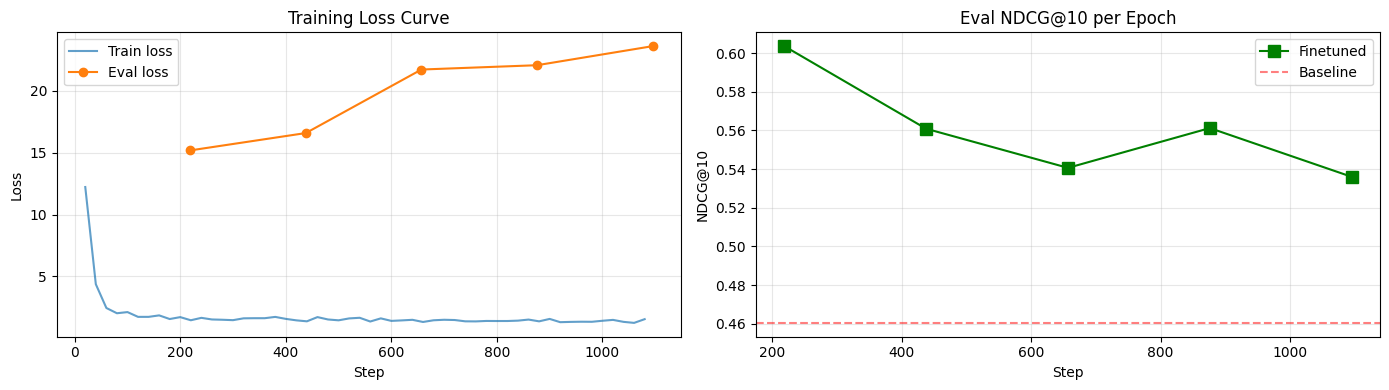

In [23]:
# Training curves
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_steps = [x["step"] for x in log_history if "loss" in x]
train_loss = [x["loss"] for x in log_history if "loss" in x]
eval_steps = [x["step"] for x in log_history if "eval_loss" in x]
eval_loss = [x["eval_loss"] for x in log_history if "eval_loss" in x]

# NDCG@10 per epoch
ndcg_key = f"eval_{EVAL_NAME}_cosine_ndcg@10"
ndcg_steps = [x["step"] for x in log_history if ndcg_key in x]
ndcg_vals = [x[ndcg_key] for x in log_history if ndcg_key in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss curve
ax1.plot(train_steps, train_loss, label="Train loss", alpha=0.7)
if eval_loss:
    ax1.plot(eval_steps, eval_loss, "o-", label="Eval loss", markersize=6)
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss Curve")
ax1.legend()
ax1.grid(True, alpha=0.3)

# NDCG@10 curve
if ndcg_vals:
    ax2.plot(ndcg_steps, ndcg_vals, "s-", color="green", markersize=8, label="Finetuned")
    ax2.axhline(y=baseline_results.get("NDCG@10", 0), color="red",
                linestyle="--", label="Baseline", alpha=0.5)
    ax2.set_xlabel("Step")
    ax2.set_ylabel("NDCG@10")
    ax2.set_title("Eval NDCG@10 per Epoch")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Save & Download

In [26]:
final_path = f"{OUTPUT_DIR}/final"
model.save_pretrained(final_path)
print(f"Model saved to: {final_path}")

model.push_to_hub("SalahAbdoNLP/jina-v5-nano-arabic-dict-v2", exist_ok=True)


for f in sorted(Path(final_path).rglob("*")):
    if f.is_file():
        print(f"  {f.relative_to(final_path)} ({f.stat().st_size/1e6:.1f} MB)")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/jina-v5-nano-finetuned-v2/final


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  1_Pooling/config.json (0.0 MB)
  README.md (0.1 MB)
  config.json (0.0 MB)
  config_sentence_transformers.json (0.0 MB)
  configuration_eurobert.py (0.0 MB)
  model.safetensors (847.1 MB)
  modeling_eurobert.py (0.0 MB)
  modules.json (0.0 MB)
  sentence_bert_config.json (0.0 MB)
  tokenizer.json (17.2 MB)
  tokenizer_config.json (0.0 MB)


In [27]:
# Package model as ZIP for download from Kaggle Output tab
import zipfile

zip_path = "/kaggle/working/jina_v5_nano_finetuned_v2.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, fnames in os.walk(final_path):
        for fname in fnames:
            fpath = os.path.join(root, fname)
            arcname = os.path.relpath(fpath, final_path)
            z.write(fpath, arcname)
            print(f"  {arcname} ({os.path.getsize(fpath)/1e6:.1f} MB)")

total_mb = os.path.getsize(zip_path) / 1e6
print(f"\nZip: {zip_path} ({total_mb:.0f} MB)")
print("Download from Kaggle Output tab.")

  configuration_eurobert.py (0.0 MB)
  model.safetensors (847.1 MB)
  config.json (0.0 MB)
  modeling_eurobert.py (0.0 MB)
  modules.json (0.0 MB)
  tokenizer_config.json (0.0 MB)
  tokenizer.json (17.2 MB)
  config_sentence_transformers.json (0.0 MB)
  README.md (0.1 MB)
  sentence_bert_config.json (0.0 MB)
  1_Pooling/config.json (0.0 MB)

Zip: /kaggle/working/jina_v5_nano_finetuned_v2.zip (624 MB)
Download from Kaggle Output tab.


## Notes

### Production Eval Contamination (P2-9)

The production evaluation in `queries.py` uses `select_test_synsets()` which draws
from the SAME prepared synset pool used for training data generation. ~70% of test
synsets overlap with training synsets, inflating production eval metrics.

This is an **eval-code issue**, not a training issue. To fix, modify `queries.py`
to exclude the 137 synsets used in `build_finetuning_data.py`. The remaining pool
has 206 - 137 = 69 clean synsets for uncontaminated evaluation.

The in-notebook evaluation above IS clean: the train/eval synset split in
`build_finetuning_data.py` (line 529) ensures no synset appears in both splits.

### Model Deployment

When deploying the finetuned model:
1. Copy pipeline config files (`modules.json`, `1_Pooling/config.json`,
   `config_sentence_transformers.json`) from the base model repo — the Trainer
   may not save these.
2. Copy custom architecture code (`configuration_eurobert.py`, `modeling_eurobert.py`)
   from the base model repo — needed for `trust_remote_code=True`.
3. Patch `tokenizer_config.json`: set `"tokenizer_class": "PreTrainedTokenizer"`
   if it contains `"TokenizersBackend"` (a transformers v5.0 artifact).
4. Verify **last-token pooling** is configured (not mean pooling) — check
   `1_Pooling/config.json` for `"pooling_mode_lasttoken": true`.

## (Optional) Finetune v5-small with LoRA

The v5-small model (677M params, 1024-dim) is more powerful but too large
for full finetuning on T4. LoRA freezes base weights and trains lightweight
adapter matrices (~6.7M trainable params).

**Skip this section if v5-nano results are sufficient.**

In [29]:
# Free nano model VRAM
del model, trainer, loss, inner_loss, evaluator
gc.collect()
torch.cuda.empty_cache()

for i in range(torch.cuda.device_count()):
    free, total = torch.cuda.mem_get_info(i)
    print(f"GPU {i}: {free/1e9:.1f} GB free / {total/1e9:.1f} GB total")


GPU 0: 11.5 GB free / 15.6 GB total
GPU 1: 12.8 GB free / 15.6 GB total


In [31]:
from peft import LoraConfig, TaskType

SMALL_MODEL_ID = "jinaai/jina-embeddings-v5-text-small-retrieval"

model_small = SentenceTransformer(
    SMALL_MODEL_ID,
    trust_remote_code=True,
    model_kwargs={"dtype": torch.float16},
)
model_small.max_seq_length = 512

print(f"Model: {SMALL_MODEL_ID}")
print(f"Parameters: {sum(p.numel() for p in model_small.parameters()):,}")
print(f"Embedding dim: {model_small.get_sentence_embedding_dimension()}")

# Add LoRA adapter
peft_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,
    inference_mode=False,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
)
model_small.add_adapter(peft_config)

trainable = sum(p.numel() for p in model_small.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_small.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")


# Build evaluator and loss for v5-small
evaluator_small = build_evaluator(eval_decomposed, name="jina-v5-small-eval")

loss_small = MatryoshkaLoss(
    model=model_small,
    loss=CachedMultipleNegativesRankingLoss(model_small, mini_batch_size=8),
    matryoshka_dims=[1024, 768, 512, 256, 128, 64, 32],  # v5-small has 1024-dim
    matryoshka_weights=[1.0] * 7,
)

SMALL_EVAL_NAME = "jina-v5-small-eval"

args_small = SentenceTransformerTrainingArguments(
    output_dir="/kaggle/working/jina-v5-small-finetuned",
    num_train_epochs=2,                    # FIX: nano overfit after epoch 1; 2 is plenty
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    warmup_steps=0.1,                      # FIX: warmup_ratio deprecated in Transformers v5
    lr_scheduler_type="cosine",
    fp16=False,
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model=f"{SMALL_EVAL_NAME}_cosine_ndcg@10",
    greater_is_better=True,
    logging_steps=20,
    report_to="wandb",
    run_name="jina-v5-small-arabic-dict-v2-lora",
    push_to_hub=True,
    hub_model_id="SalahAbdoNLP/jina-v5-small-arabic-dict-v2-lora",
    hub_strategy="every_save",
)

trainer_small = SentenceTransformerTrainer(
    model=model_small, args=args_small,
    train_dataset=train_dataset, eval_dataset=eval_dataset,
    loss=loss_small, evaluator=evaluator_small,
)

print("Training v5-small with LoRA...")
trainer_small.train()
print("Training complete!")

# Save
model_small.save_pretrained("/kaggle/working/jina-v5-small-finetuned/final")
model_small.push_to_hub("SalahAbdoNLP/jina-v5-small-arabic-dict-v2-lora", exist_ok=True)
print("v5-small LoRA adapter saved and pushed to Hub.")


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Model: jinaai/jina-embeddings-v5-text-small-retrieval
Parameters: 596,049,920
Embedding dim: 1024
Trainable: 4,587,520 / 600,637,440 (0.76%)


Evaluator 'jina-v5-small-eval':
  Queries:            84
  Corpus docs:        861
  Relevance judgments: 150


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Training v5-small with LoRA...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

v5-small LoRA adapter saved and pushed to Hub.
